In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('C:/a/run/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [76]:
df.drop(['sex','region'], axis=1, inplace=True)

In [77]:
df

,age,bmi,children,smoker,charges
0,19,27.900,0,yes,16884.92400
1,18,33.770,1,no,1725.55230
2,28,33.000,3,no,4449.46200
3,33,22.705,0,no,21984.47061
4,32,28.880,0,no,3866.85520
...,...,...,...,...,...
1333,50,30.970,3,no,10600.54830
1334,18,31.920,0,no,2205.98080
1335,18,36.850,0,no,1629.83350
1336,21,25.800,0,no,2007.94500


In [78]:
from sklearn.preprocessing import LabelEncoder

la=LabelEncoder()
la.fit(['yes','no'])
df['smoker']=la.transform(df['smoker'])

In [79]:
df

,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.92400
1,18,33.770,1,0,1725.55230
2,28,33.000,3,0,4449.46200
3,33,22.705,0,0,21984.47061
4,32,28.880,0,0,3866.85520
...,...,...,...,...,...
1333,50,30.970,3,0,10600.54830
1334,18,31.920,0,0,2205.98080
1335,18,36.850,0,0,1629.83350
1336,21,25.800,0,0,2007.94500


In [80]:
df.isna().sum()

age         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [81]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
df_scaled=sc.fit_transform(df)

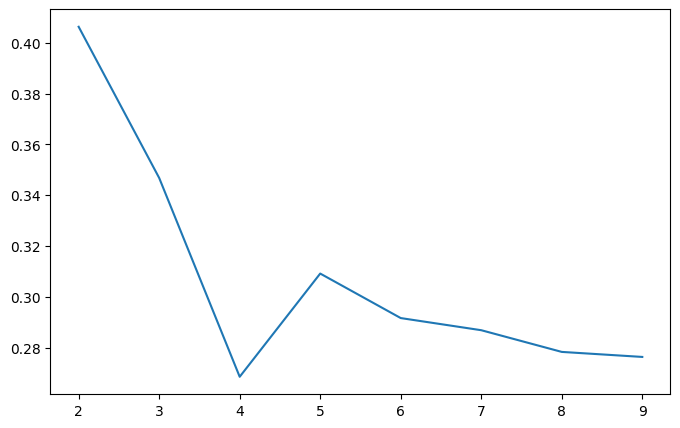

In [82]:
k_range=range(2,10)
silhouette_grade=[]

for i in k_range:
    kmeans=KMeans(n_clusters=i, random_state=1)
    labels=kmeans.fit_predict(df_scaled)
    grade=silhouette_score(df_scaled, labels)
    silhouette_grade.append(grade)

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_grade)
plt.show()

In [83]:
silhouette_grade=[]

kmeans=KMeans(n_clusters=5, random_state=1)
labels=kmeans.fit_predict(df_scaled)
grade=silhouette_score(df_scaled, labels)
silhouette_grade.append(grade)


In [84]:
silhouette_grade

[0.30919375828187423]

In [85]:
df['ClusterLabel']=kmeans.fit_predict(df_scaled)

In [86]:
df

,age,bmi,children,smoker,charges,ClusterLabel
0,19,27.900,0,1,16884.92400,1
1,18,33.770,1,0,1725.55230,0
2,28,33.000,3,0,4449.46200,3
3,33,22.705,0,0,21984.47061,0
4,32,28.880,0,0,3866.85520,0
...,...,...,...,...,...,...
1333,50,30.970,3,0,10600.54830,3
1334,18,31.920,0,0,2205.98080,0
1335,18,36.850,0,0,1629.83350,0
1336,21,25.800,0,0,2007.94500,0


In [92]:
age_mean=df.groupby('ClusterLabel')['age'].mean().reset_index()
age_mean

,ClusterLabel,age
0,0,25.595855
1,1,36.848485
2,2,40.063380
3,3,40.270627
4,4,52.864000


In [93]:
bmi_mean=df.groupby('ClusterLabel')['bmi'].mean().reset_index()
bmi_mean

,ClusterLabel,bmi
0,0,29.486580
1,1,25.452083
2,2,35.594648
3,3,30.928432
4,4,31.627667


In [96]:
smoker_mean=df.groupby('ClusterLabel')['smoker'].mean().reset_index()
smoker_mean

,ClusterLabel,smoker
0,0,0.0
1,1,1.0
2,2,1.0
3,3,0.0
4,4,0.0


In [97]:
children_mean=df.groupby('ClusterLabel')['children'].mean().reset_index()
children_mean

,ClusterLabel,children
0,0,0.445596
1,1,1.060606
2,2,1.161972
3,3,2.702970
4,4,0.450667


In [98]:
charges_mean=df.groupby('ClusterLabel')['charges'].mean().reset_index()
charges_mean

,ClusterLabel,charges
0,0,4213.367663
1,1,21561.985483
2,2,41799.869282
3,3,9527.216896
4,4,11895.879551
